# 1- Data Ingestion
# 2 - Eda of the data
# 3 - processing of data
# 4 - model building
# 5 - model evaluation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import sys

In [2]:
data = pd.read_csv("tesla.csv")

In [3]:
data.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-07-01,5.000,5.184,4.054,4.392,4.392,41094000
1,2010-07-02,4.600,4.620,3.742,3.840,3.840,25699000
2,2010-07-06,4.000,4.000,3.166,3.222,3.222,34334500
3,2010-07-07,3.280,3.326,2.996,3.160,3.160,34608500
4,2010-07-08,3.228,3.504,3.114,3.492,3.492,38557000


In [4]:
stock_data = data[['Date','Close']]

In [5]:
stock_data

,Date,Close
0,2010-07-01,4.392000
1,2010-07-02,3.840000
2,2010-07-06,3.222000
3,2010-07-07,3.160000
4,2010-07-08,3.492000
...,...,...
2838,2021-10-08,785.489990
2839,2021-10-11,791.940002
2840,2021-10-12,805.719971
2841,2021-10-13,811.080017


In [6]:
stock_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2843 entries, 0 to 2842
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2843 non-null   str    
 1   Close   2843 non-null   float64
dtypes: float64(1), str(1)
memory usage: 72.3 KB


In [7]:
stock_data['Date'] = pd.to_datetime(stock_data["Date"])

In [8]:
stock_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2843 entries, 0 to 2842
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2843 non-null   datetime64[us]
 1   Close   2843 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 44.6 KB


In [9]:
stock_data.head()

,Date,Close
0,2010-07-01,4.392
1,2010-07-02,3.840
2,2010-07-06,3.222
3,2010-07-07,3.160
4,2010-07-08,3.492


#why u are converting date column to index
# 1- easily retrive data
# 2 - visualization is easy
# 3 - those lib has been design in such way it required date column as index

In [10]:
stock_data = stock_data.set_index('Date')

In [11]:
stock_data

,Close
Date,
2010-07-01,4.392000
2010-07-02,3.840000
2010-07-06,3.222000
2010-07-07,3.160000
2010-07-08,3.492000
...,...
2021-10-08,785.489990
2021-10-11,791.940002
2021-10-12,805.719971


## EDA

In [12]:
stock_data.describe()

,Close
count,2843.000000
mean,105.924597
std,188.836358
min,3.160000
25%,10.727000
50%,45.916000
75%,65.275002
max,883.090027


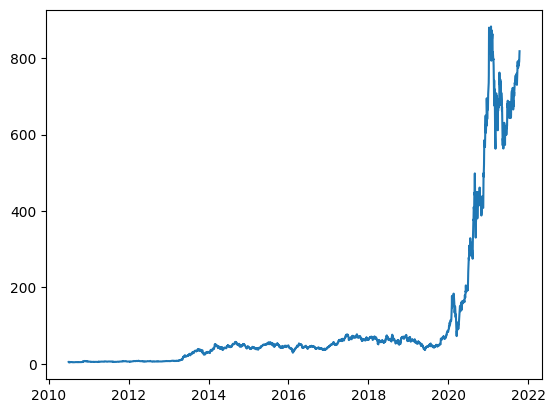

In [13]:
plt.plot(stock_data.Close)

(array([2402.,   94.,   23.,   31.,   55.,   14.,   37.,   94.,   63.,
          30.]),
 array([  3.16     ,  91.1530027, 179.1460054, 267.1390081, 355.1320108,
        443.1250135, 531.1180162, 619.1110189, 707.1040216, 795.0970243,
        883.090027 ]),
 <BarContainer object of 10 artists>)

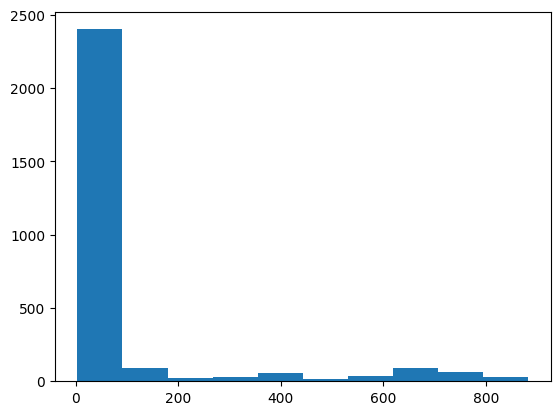

In [14]:
plt.hist(stock_data.Close)

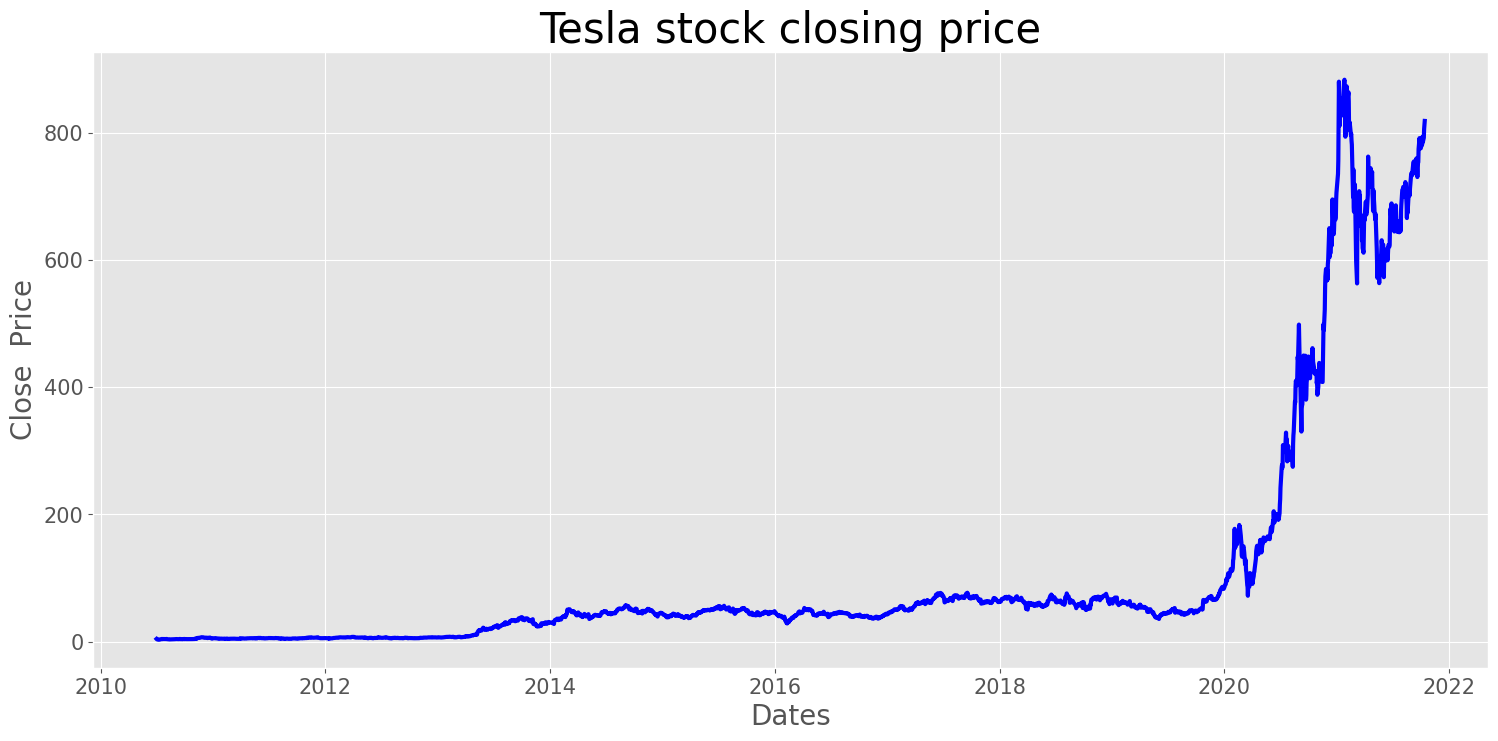

In [15]:
## ploting close price
plt.style.use('ggplot')
plt.figure(figsize=(18,8))
plt.grid(True)
plt.xlabel('Dates' , fontsize = 20)
plt.xticks(fontsize = 15)
plt.ylabel('Close  Price' , fontsize =20)
plt.yticks(fontsize=15)
plt.plot(stock_data['Close'] , linewidth = 3 , color ='blue')
plt.title("Tesla stock closing price" , fontsize = 30)
plt.show()

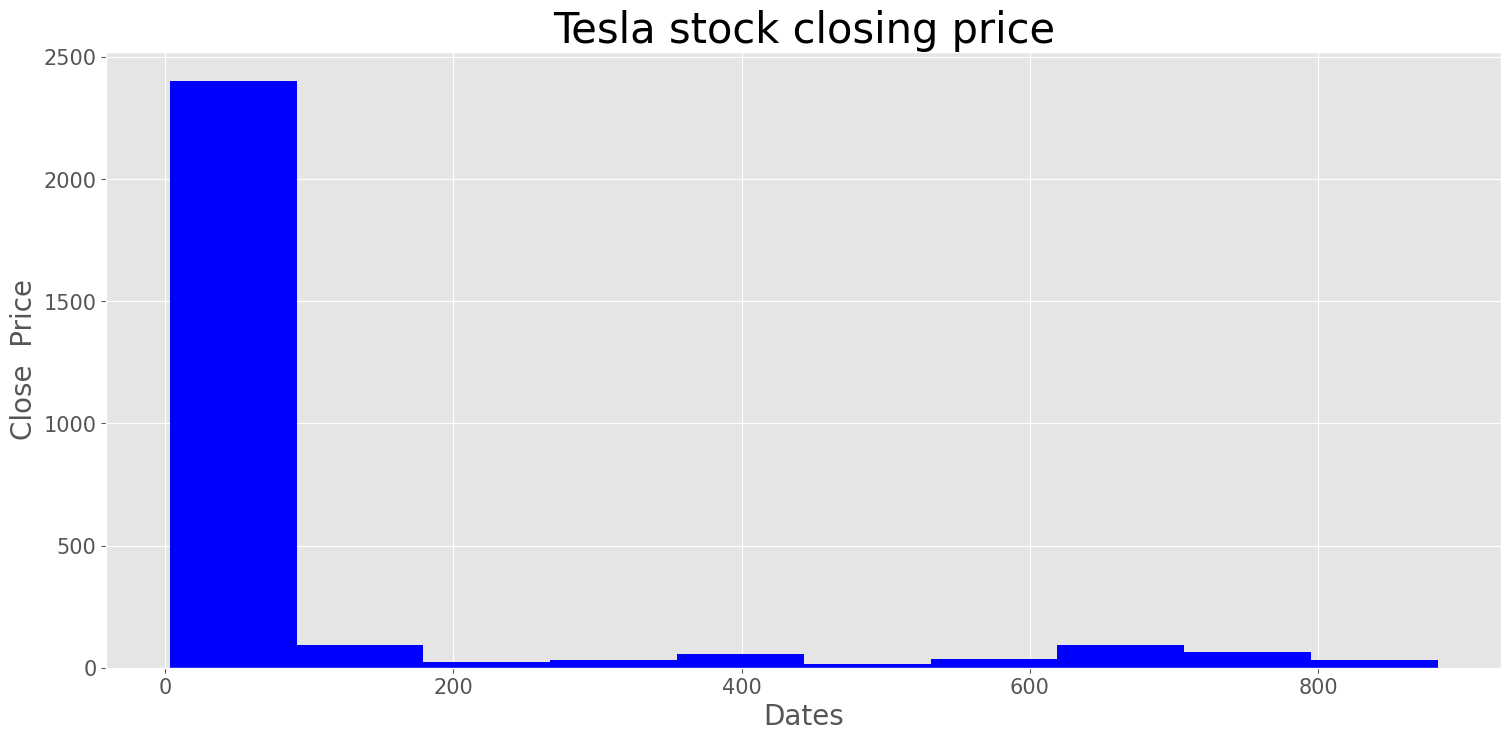

In [16]:
plt.style.use('ggplot')
plt.figure(figsize=(18,8))
plt.grid(True)
plt.xlabel('Dates' , fontsize = 20)
plt.xticks(fontsize = 15)
plt.ylabel('Close  Price' , fontsize =20)
plt.yticks(fontsize=15)
plt.hist(stock_data['Close'] , linewidth = 3 , color ='blue')
plt.title("Tesla stock closing price" , fontsize = 30)
plt.show()

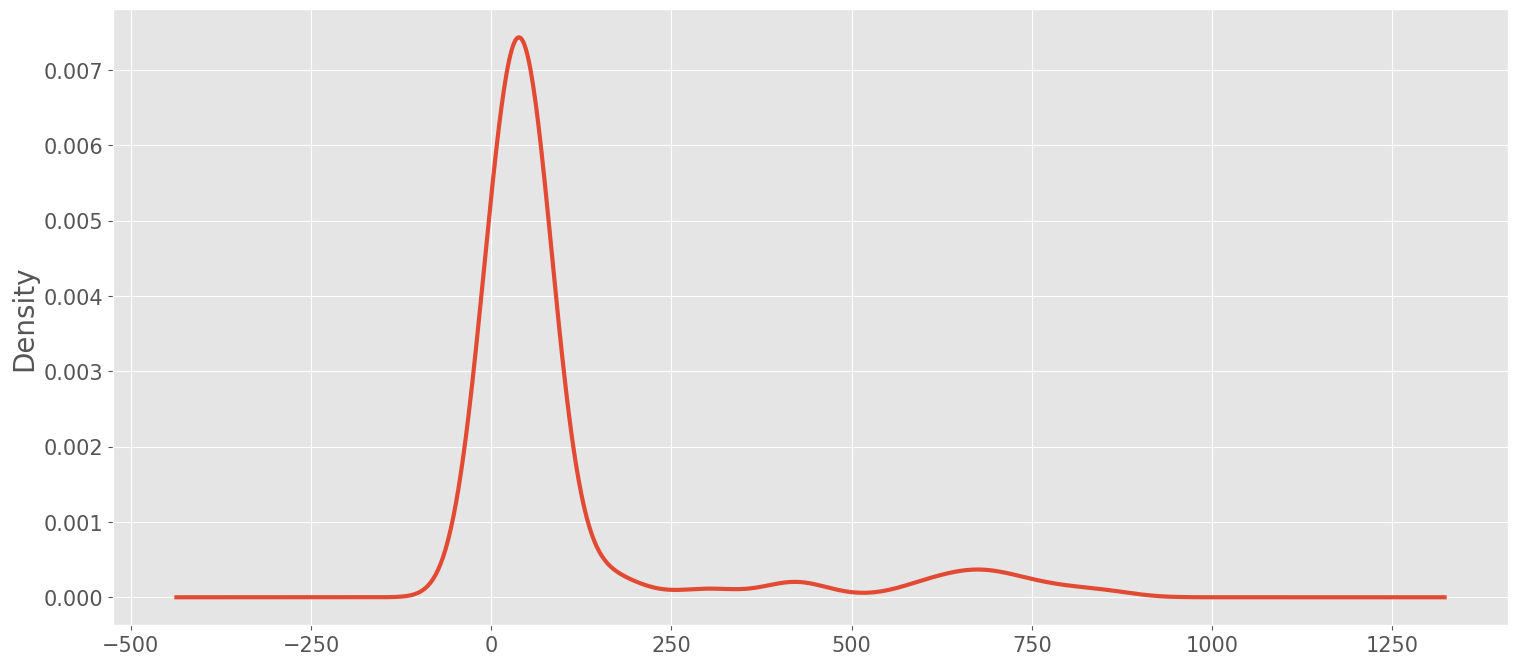

In [17]:
df_close = stock_data['Close']
df_close.plot(kind ='kde' , figsize=(18,8), linewidth =3)
plt.xticks(fontsize = 15)
plt.grid('both')
plt.ylabel('Density' , fontsize = 20)
plt.yticks(fontsize = 15)
plt.show()

In [18]:
rolmean = stock_data['Close'].rolling(48).mean()
rolstd = stock_data['Close'].rolling(48).std()

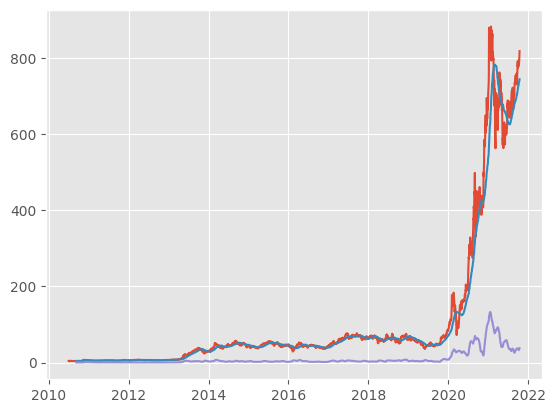

In [19]:
plt.plot(stock_data.Close)
plt.plot(rolmean)
plt.plot(rolstd)

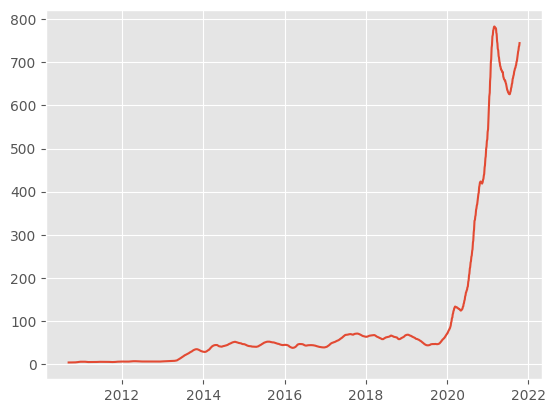

In [20]:
plt.plot(rolmean)

In [21]:
from statsmodels.tsa.stattools import adfuller
adft = adfuller (stock_data['Close'])

In [22]:
pd.Series(adft[0:4] , index =['test_stats' , 'p_value' , 'lag' ,'data_points'])

test_stats        2.293095
p_value           0.998951
lag              28.000000
data_points    2814.000000
dtype: float64

In [30]:
def test_stationarity(timeseries):
    ## Deleting rolling statistics
    rolmean = timeseries.rolling(48).mean() # rolling mean
    rolstd = timeseries.rolling(48).std() # rolling standard deviation
    ##plot roling statistics
    plt.figure(figsize = (18,8))
    plt.grid('both')
    plt.plot(timeseries , color ='blue' , label = 'original' , linewidth = 3)
    plt.plot(rolmean , color ='red' , label = 'Rolling Mean' , linewidth = 3)
    plt.plot(rolstd , color ='black' , label = 'Rolling Std' , linewidth = 3)
    plt.legend(loc ='best' , fontsize = 20 , shadow=True, facecolor = 'lightpink' ,edgecolor ='k')
    plt.title('Rolling Mean and Standard Deviatio' , fontsize=25)
    plt.xticks(fontsize = 15)
    plt.yticks(fontsize  = 15)
    plt.show(block = False)

    print("Result of dickey fuller test")
    adft = adfuller(timeseries , autolag ='AIC')


    output = pd.Series(adft[0:4] , index =['Test Statistics' , 'p_value' , 'No. of lags used' , 'Number of observation'])
    for key , value in adft[4].items():
        output['critical value (%s)' %key] = value
        print(output)

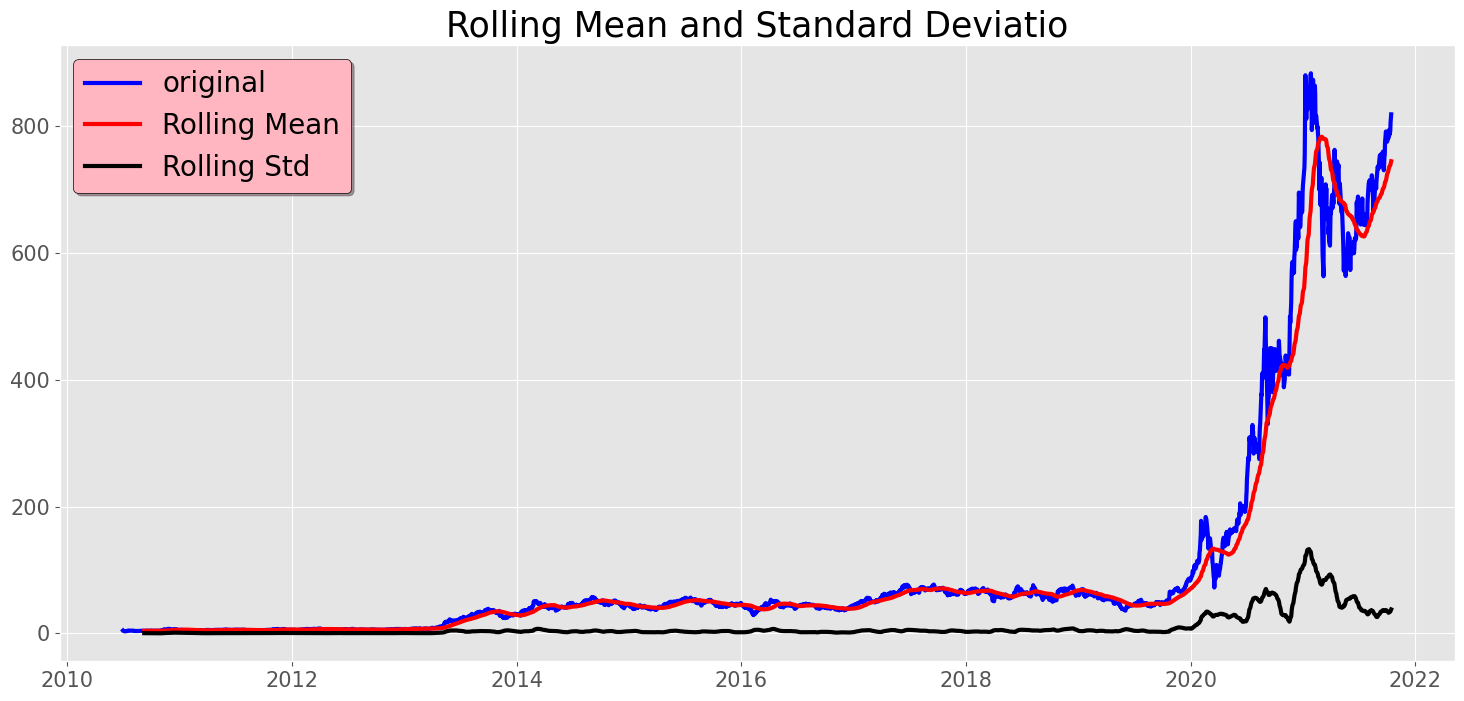

Result of dickey fuller test
Test Statistics             2.293095
p_value                     0.998951
No. of lags used           28.000000
Number of observation    2814.000000
critical value (1%)        -3.432676
dtype: float64
Test Statistics             2.293095
p_value                     0.998951
No. of lags used           28.000000
Number of observation    2814.000000
critical value (1%)        -3.432676
critical value (5%)        -2.862568
dtype: float64
Test Statistics             2.293095
p_value                     0.998951
No. of lags used           28.000000
Number of observation    2814.000000
critical value (1%)        -3.432676
critical value (5%)        -2.862568
critical value (10%)       -2.567317
dtype: float64


In [31]:
test_stationarity(stock_data.Close)

In [33]:
from statsmodels.tsa.seasonal import seasonal_decompose
result =seasonal_decompose(stock_data[['Close']],period =12)

In [34]:
result.seasonal

Date
2010-07-01   -0.212491
2010-07-02    0.138005
2010-07-06    0.128027
2010-07-07    0.377724
2010-07-08    0.518241
                ...   
2021-10-08   -0.191872
2021-10-11    0.033079
2021-10-12   -0.343643
2021-10-13    0.194169
2021-10-14   -0.565314
Name: seasonal, Length: 2843, dtype: float64

<Figure size 2000x1000 with 0 Axes>

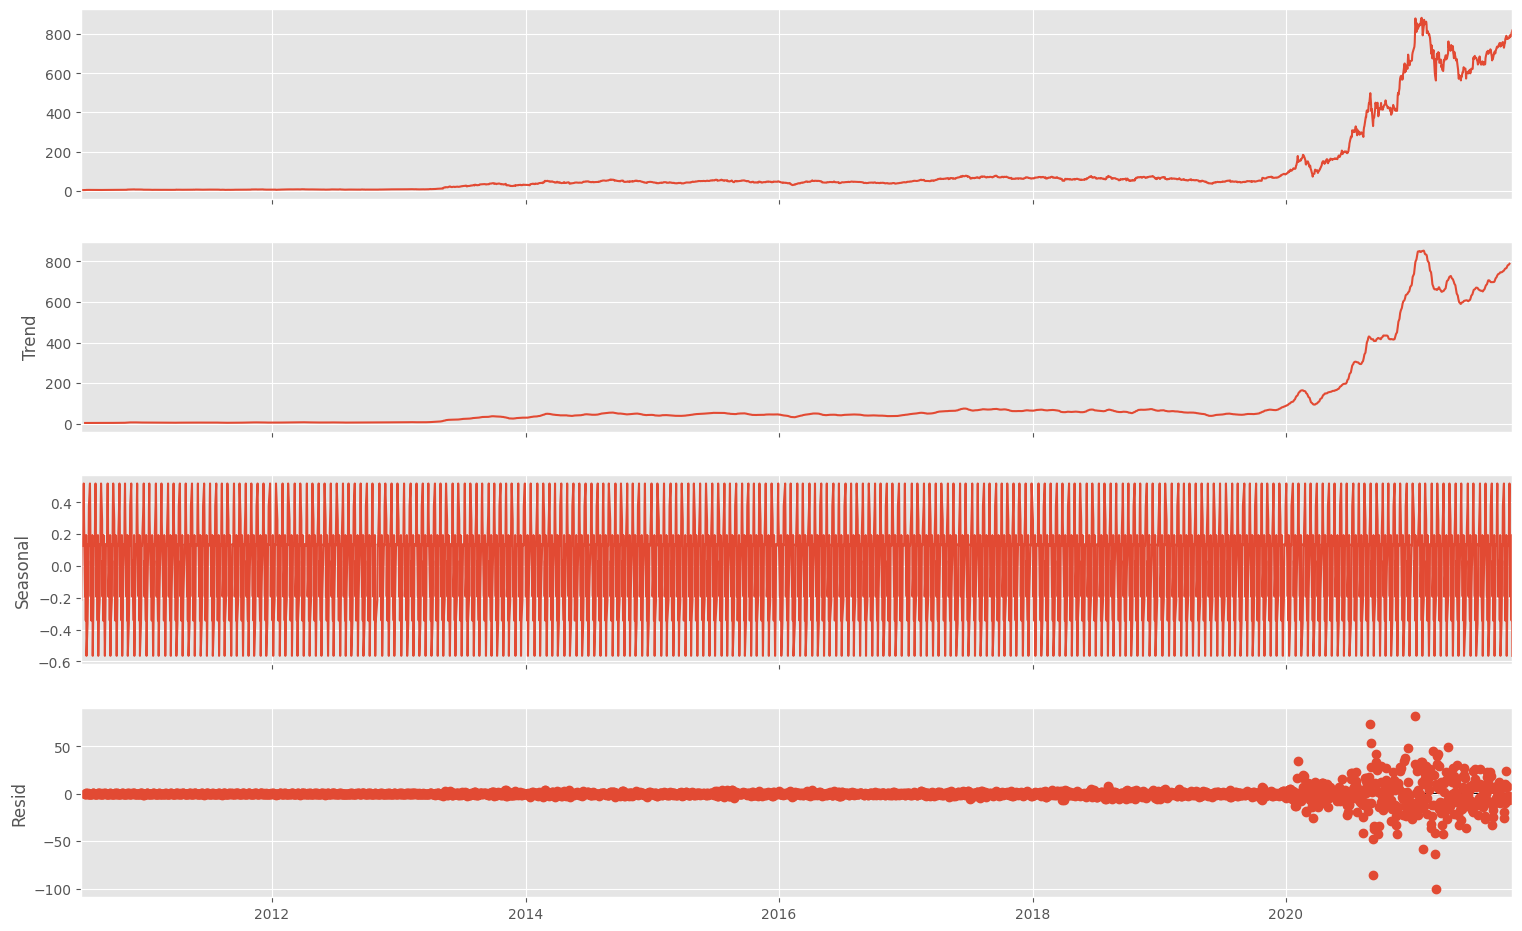

In [35]:
fig = plt.figure(figsize =(20,10))
fig = result.plot()
fig.set_size_inches(17,10)

In [36]:
from statsmodels.tsa.seasonal import seasonal_decompose
result =seasonal_decompose(stock_data[['Close']],period =12 , model= 'multiplicative')

<Figure size 2000x1000 with 0 Axes>

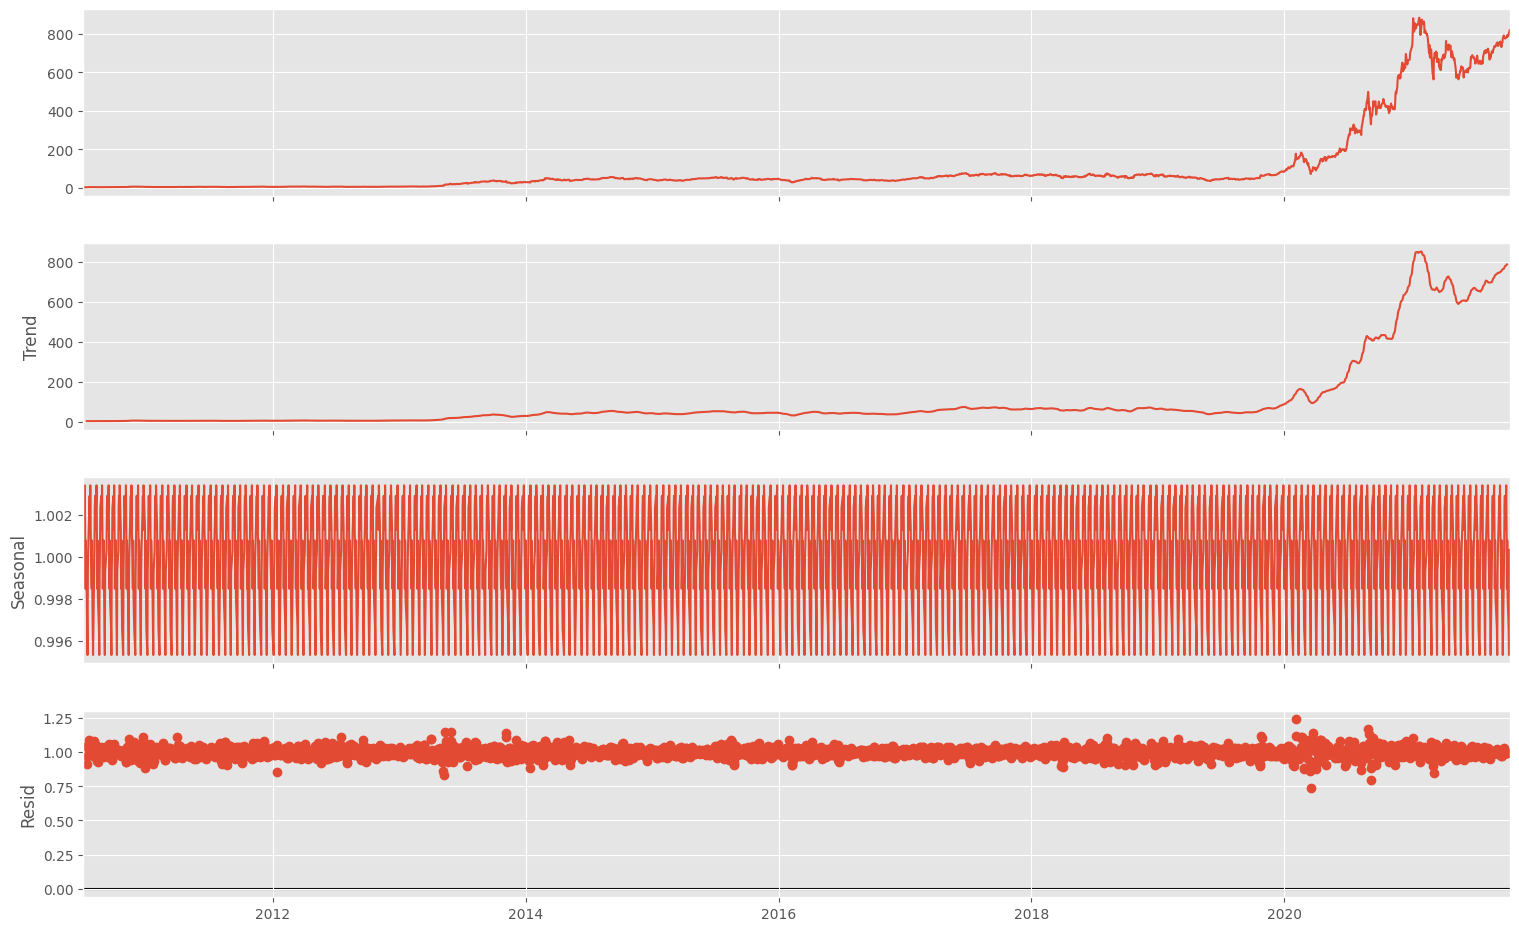

In [37]:
fig = plt.figure(figsize =(20,10))
fig = result.plot()
fig.set_size_inches(17,10)

<Axes: ylabel='Close'>

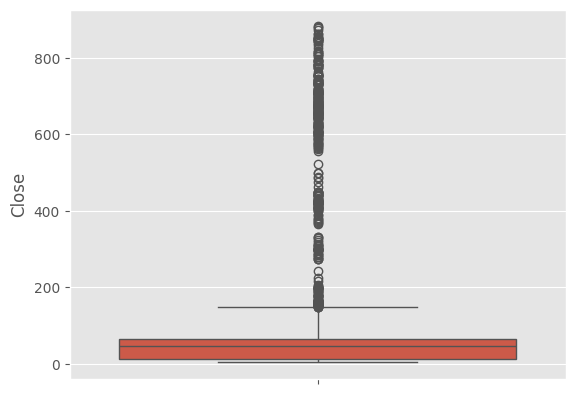

In [39]:
import seaborn as sns
sns.boxplot(stock_data.Close)

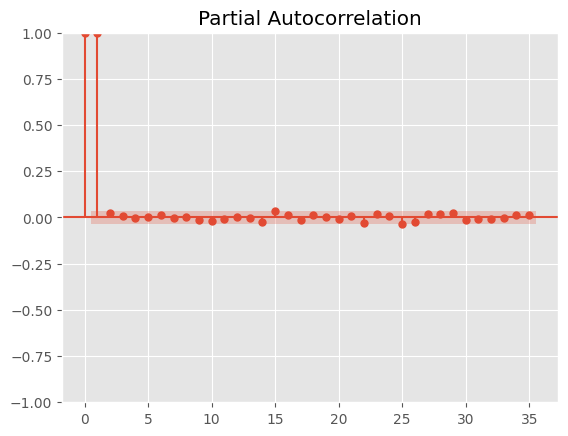

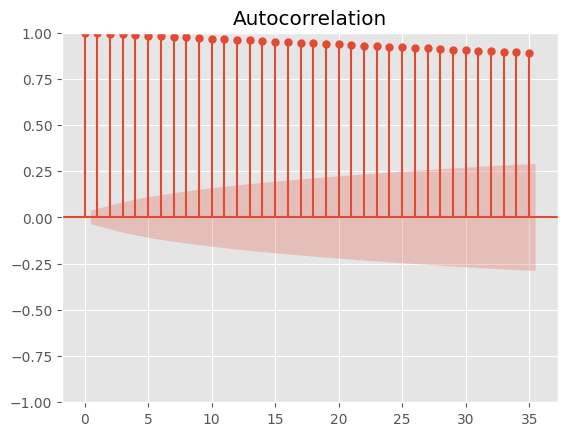

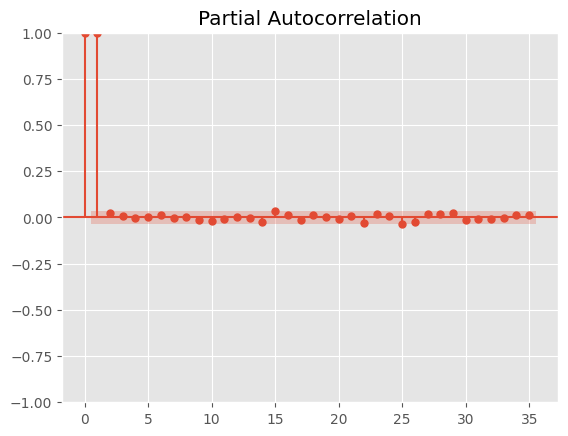

In [43]:
from statsmodels.graphics.tsaplots import plot_acf , plot_pacf
plot_acf(stock_data.Close)
plot_pacf(stock_data.Close)

## convert non stationary data to stationary

In [44]:
df_close = stock_data['Close']

In [45]:
df_close

Date
2010-07-01      4.392000
2010-07-02      3.840000
2010-07-06      3.222000
2010-07-07      3.160000
2010-07-08      3.492000
                 ...    
2021-10-08    785.489990
2021-10-11    791.940002
2021-10-12    805.719971
2021-10-13    811.080017
2021-10-14    818.320007
Name: Close, Length: 2843, dtype: float64

In [48]:
df_close = df_close.diff()

In [50]:
 df_close = df_close.dropna()

In [51]:
df_close

Date
2010-07-02    -0.552000
2010-07-06    -0.618000
2010-07-07    -0.062000
2010-07-08     0.332000
2010-07-09    -0.012000
                ...    
2021-10-08    -8.119995
2021-10-11     6.450012
2021-10-12    13.779969
2021-10-13     5.360046
2021-10-14     7.239990
Name: Close, Length: 2842, dtype: float64

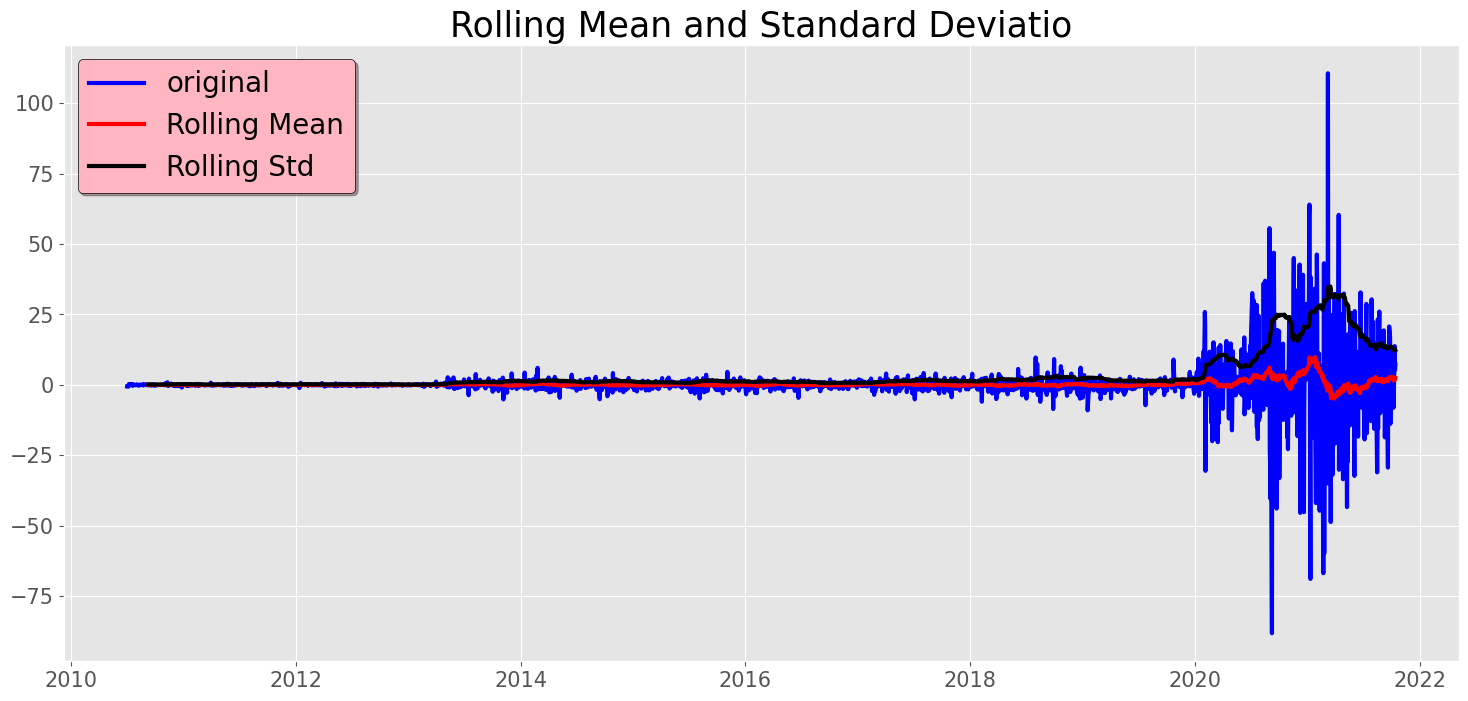

Result of dickey fuller test
Test Statistics         -8.944289e+00
p_value                  9.076468e-15
No. of lags used         2.800000e+01
Number of observation    2.813000e+03
critical value (1%)     -3.432677e+00
dtype: float64
Test Statistics         -8.944289e+00
p_value                  9.076468e-15
No. of lags used         2.800000e+01
Number of observation    2.813000e+03
critical value (1%)     -3.432677e+00
critical value (5%)     -2.862568e+00
dtype: float64
Test Statistics         -8.944289e+00
p_value                  9.076468e-15
No. of lags used         2.800000e+01
Number of observation    2.813000e+03
critical value (1%)     -3.432677e+00
critical value (5%)     -2.862568e+00
critical value (10%)    -2.567317e+00
dtype: float64


In [53]:
test_stationarity(df_close)

In [54]:
df_close[-0:-60]

Date
2010-07-02    -0.552000
2010-07-06    -0.618000
2010-07-07    -0.062000
2010-07-08     0.332000
2010-07-09    -0.012000
                ...    
2021-07-15    -2.780029
2021-07-16    -6.380005
2021-07-19     2.000000
2021-07-20    14.280029
2021-07-21    -5.210022
Name: Close, Length: 2782, dtype: float64

In [57]:
df_close[-60:]

Date
2021-07-22    -6.029968
2021-07-23    -5.880005
2021-07-26    14.239990
2021-07-27   -12.839966
2021-07-28     2.199951
2021-07-29    30.369996
2021-07-30     9.850036
2021-08-02    22.469971
2021-08-03     0.070007
2021-08-04     1.179993
2021-08-05     3.710022
2021-08-06   -15.530029
2021-08-09    14.660034
2021-08-10    -3.770020
2021-08-11    -2.169983
2021-08-12    14.429993
2021-08-13    -5.080017
2021-08-16   -31.000000
2021-08-17   -20.459961
2021-08-18    23.279968
2021-08-19   -15.520019
2021-08-20     6.790039
2021-08-23    26.039978
2021-08-24     2.190002
2021-08-25     2.710022
2021-08-26   -10.040039
2021-08-27    10.760010
2021-08-30    18.989990
2021-08-31     4.809998
2021-09-01    -1.629944
2021-09-02    -1.700012
2021-09-03     1.179992
2021-09-07    19.349976
2021-09-08     0.950012
2021-09-09     0.989990
2021-09-10   -18.589965
2021-09-13     6.729980
2021-09-14     1.489990
2021-09-15    11.340027
2021-09-16     1.159973
2021-09-17     2.500000
2021-09-20 

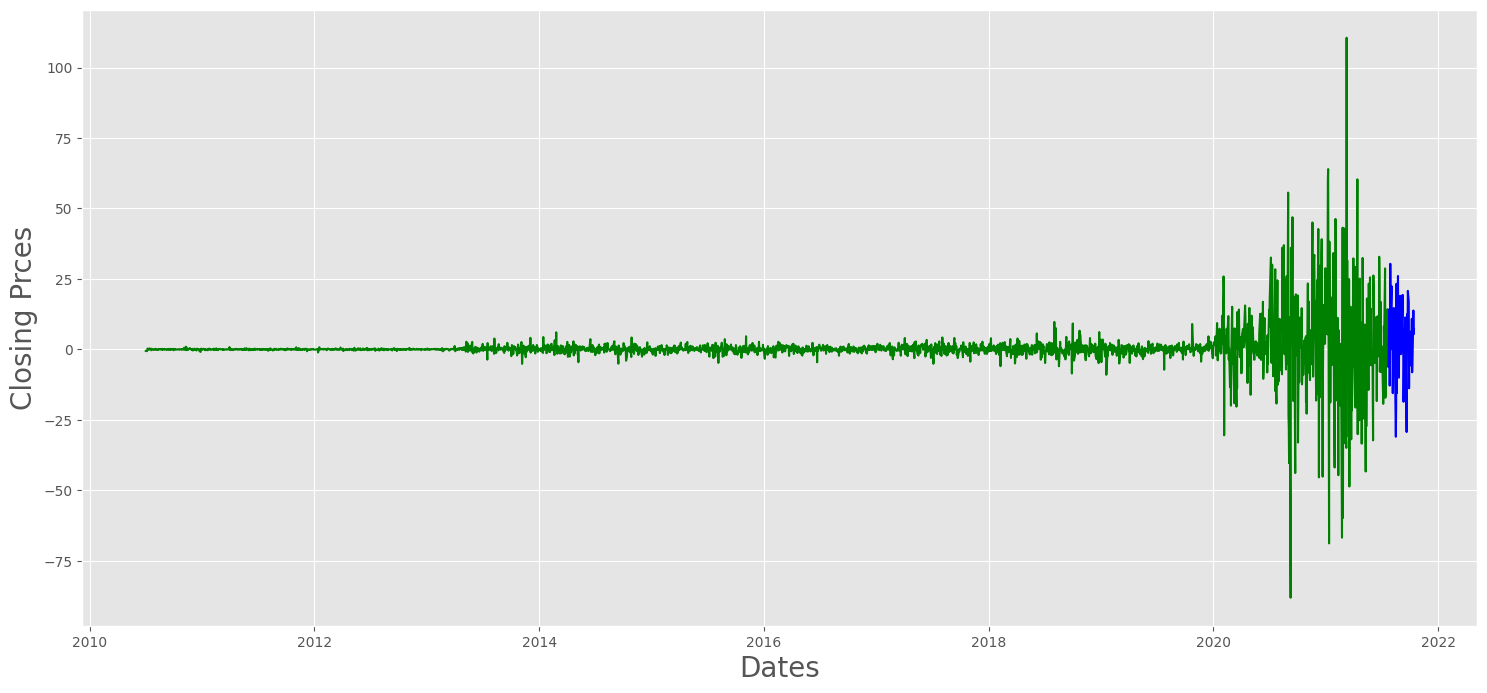

In [60]:
train_data = df_close[0:-60]
test_data = df_close[-60:]
plt.figure(figsize =(18,8))
plt.grid(True)
plt.xlabel('Dates' , fontsize = 20)
plt.ylabel('Closing Prces' , fontsize = 20)
plt.plot(train_data , 'green' , label='Train Data')
plt.plot(test_data , 'blue' , label = 'Test Data')

## Model Building

In [61]:
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error , mean_absolute_error

In [62]:
history = [x for x in train_data]

In [63]:
history

[-0.5520000000000005,
 -0.6179999999999999,
 -0.06199999999999983,
 0.33199999999999985,
 -0.01200000000000001,
 -0.06999999999999984,
 0.21799999999999997,
 0.33999999999999986,
 0.010000000000000231,
 0.1499999999999999,
 0.25399999999999956,
 -0.32200000000000006,
 -0.016000000000000014,
 0.15600000000000058,
 0.05799999999999983,
 -0.06799999999999962,
 -0.08000000000000007,
 0.03399999999999981,
 -0.07399999999999984,
 -0.0820000000000003,
 0.19600000000000017,
 0.20599999999999952,
 -0.1379999999999999,
 -0.16199999999999992,
 -0.1719999999999997,
 0.0019999999999997797,
 -0.11399999999999988,
 -0.22599999999999998,
 -0.06000000000000005,
 0.14400000000000013,
 0.09199999999999964,
 0.07400000000000029,
 -0.07600000000000007,
 0.0040000000000000036,
 0.06199999999999983,
 0.20599999999999996,
 -0.18599999999999994,
 0.14000000000000012,
 -0.029999999999999805,
 -0.010000000000000231,
 0.03400000000000025,
 -0.07800000000000029,
 0.19399999999999995,
 0.12199999999999989,
 -0.0019

In [65]:
model = ARIMA(history , order=(1,1,1))

In [66]:
model = model.fit()

In [67]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 2782
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -9563.095
Date:                Sun, 16 Aug 2026   AIC                          19132.189
Time:                        09:02:57   BIC                          19149.981
Sample:                             0   HQIC                         19138.614
                               - 2782                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0752      0.005    -14.055      0.000      -0.086      -0.065
ma.L1         -0.9971      0.000  -2145.492      0.000      -0.998      -0.996
sigma2        56.6976      0.326    173.800      0.000      56.058      57.337
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):            214282.56
Prob(Q):                              0.90   Prob(JB):                         0.00
Heteroskedasticity (H):             428.26   Skew:                             0.46
Prob(H) (two-sided):                  0.00   Kurtosis:                        45.99
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [68]:
model.forecast()[0]

np.float64(1.3145987188432704)